### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
data = pd.read_csv('C:/Users/91808/RP2 Internship/ml1/Customers (1) (1).csv')
data.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work_Experience,Family Size,Spending_Category,Invoice_Number
0,1,Male,19,15000,39,Healthcare,1,4,Average,458984
1,2,Male,21,35000,81,Engineer,3,3,High,458994
2,3,Female,20,86000,6,Engineer,1,1,Low,458994
3,4,Female,23,59000,77,Lawyer,0,2,High,458997
4,5,Female,31,38000,40,Entertainment,2,6,Average,458999


In [3]:
data.tail()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work_Experience,Family Size,Spending_Category,Invoice_Number
1995,1996,Female,71,184387,40,Artist,8,7,Average,461768
1996,1997,Female,91,73158,32,Doctor,7,7,Average,461773
1997,1998,Male,87,90961,14,Healthcare,9,2,Low,461774
1998,1999,Male,77,182109,4,Executive,7,2,Low,461775
1999,2000,Male,90,110610,52,Entertainment,5,2,High,461775


In [4]:
data.shape

(2000, 10)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         2000 non-null   int64 
 1   Gender             2000 non-null   object
 2   Age                2000 non-null   int64 
 3   Annual_Income      2000 non-null   int64 
 4   Spending_Score     2000 non-null   int64 
 5   Profession         1965 non-null   object
 6   Work_Experience    2000 non-null   int64 
 7   Family Size        2000 non-null   int64 
 8   Spending_Category  2000 non-null   object
 9   Invoice_Number     2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [6]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score',
       'Profession', 'Work_Experience', 'Family Size', 'Spending_Category',
       'Invoice_Number'],
      dtype='object')

In [7]:
data.describe()

,CustomerID,Age,Annual_Income,Spending_Score,Work_Experience,Family Size,Invoice_Number
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500,461389.611000
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749,1529.636635
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,458984.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000,459890.500000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000,461425.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000,462654.750000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000,464252.000000


In [8]:
profession = {"Marketing":0,'Lawyer':1, 'Executive':2, 'Entertainment':3, 'Healthcare':4,'Engineer':5, 'Artist':6, 'Doctor':7, 'Unknown':8, 'Homemaker':9}
data['Profession'] = data['Profession'].map(profession)

In [9]:
gender = {'Female':0,'Male':1}
data['Gender'] = data['Gender'].map(gender)

In [10]:
data.isnull().sum()

CustomerID            0
Gender                0
Age                   0
Annual_Income         0
Spending_Score        0
Profession           35
Work_Experience       0
Family Size           0
Spending_Category     0
Invoice_Number        0
dtype: int64

In [11]:
data = data.dropna()

In [12]:
data.shape

(1965, 10)

### univariate analysis

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, '0.0'),
  Text(1, 0, '1.0'),
  Text(2, 0, '2.0'),
  Text(3, 0, '3.0'),
  Text(4, 0, '4.0'),
  Text(5, 0, '5.0'),
  Text(6, 0, '6.0'),
  Text(7, 0, '7.0'),
  Text(8, 0, '9.0')])

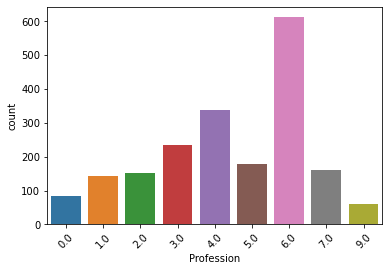

In [13]:
sns.countplot(x = data['Profession'])
plt.xticks(rotation = 45)

C:\Users\91808\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Age'>

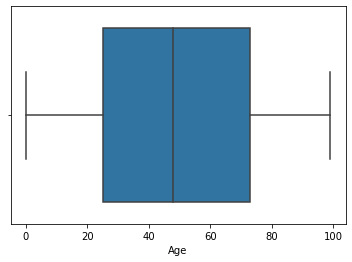

In [14]:
sns.boxplot(data['Age'])

CustomerID            AxesSubplot(0.125,0.657941;0.227941x0.222059)
Gender             AxesSubplot(0.398529,0.657941;0.227941x0.222059)
Age                AxesSubplot(0.672059,0.657941;0.227941x0.222059)
Annual_Income         AxesSubplot(0.125,0.391471;0.227941x0.222059)
Spending_Score     AxesSubplot(0.398529,0.391471;0.227941x0.222059)
Profession         AxesSubplot(0.672059,0.391471;0.227941x0.222059)
Work_Experience          AxesSubplot(0.125,0.125;0.227941x0.222059)
Family Size           AxesSubplot(0.398529,0.125;0.227941x0.222059)
Invoice_Number        AxesSubplot(0.672059,0.125;0.227941x0.222059)
dtype: object

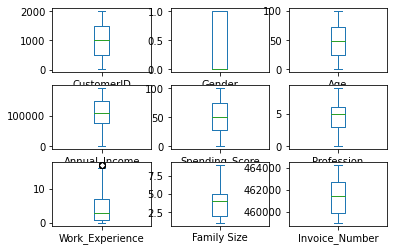

In [15]:
data.plot(kind = 'box',subplots = True,layout = (3,3), sharex=False, sharey=False)

<AxesSubplot:xlabel='Age', ylabel='Count'>

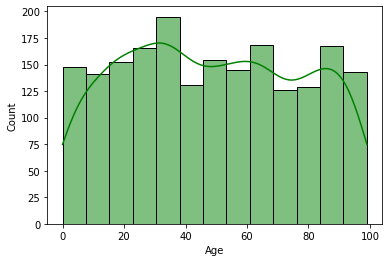

In [16]:
sns.histplot(data['Age'],kde = True,color = 'Green')

([<matplotlib.patches.Wedge at 0x23e0c718760>,
 [Text(-0.318103273495275, 1.0530006207935447, 'Female'),
  Text(0.31810317490624024, -1.053000650576518, 'Male')],
 [Text(-0.17351087645196817, 0.574363974978297, '59.34%'),
  Text(0.17351082267613102, -0.5743639912235552, '40.66%')])

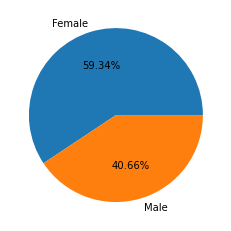

In [17]:
female = data['Gender'].value_counts()[0]
male = data['Gender'].value_counts()[1]
x = [female,male]
label = ['Female','Male']
plt.pie(x,labels = label,autopct = '%0.2f%%')

### Bivariate analysis

<AxesSubplot:xlabel='Work_Experience', ylabel='Age'>

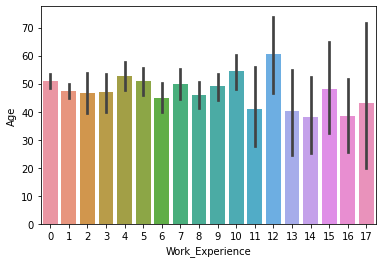

In [18]:
sns.barplot(x = data['Work_Experience'],y = data['Age'])

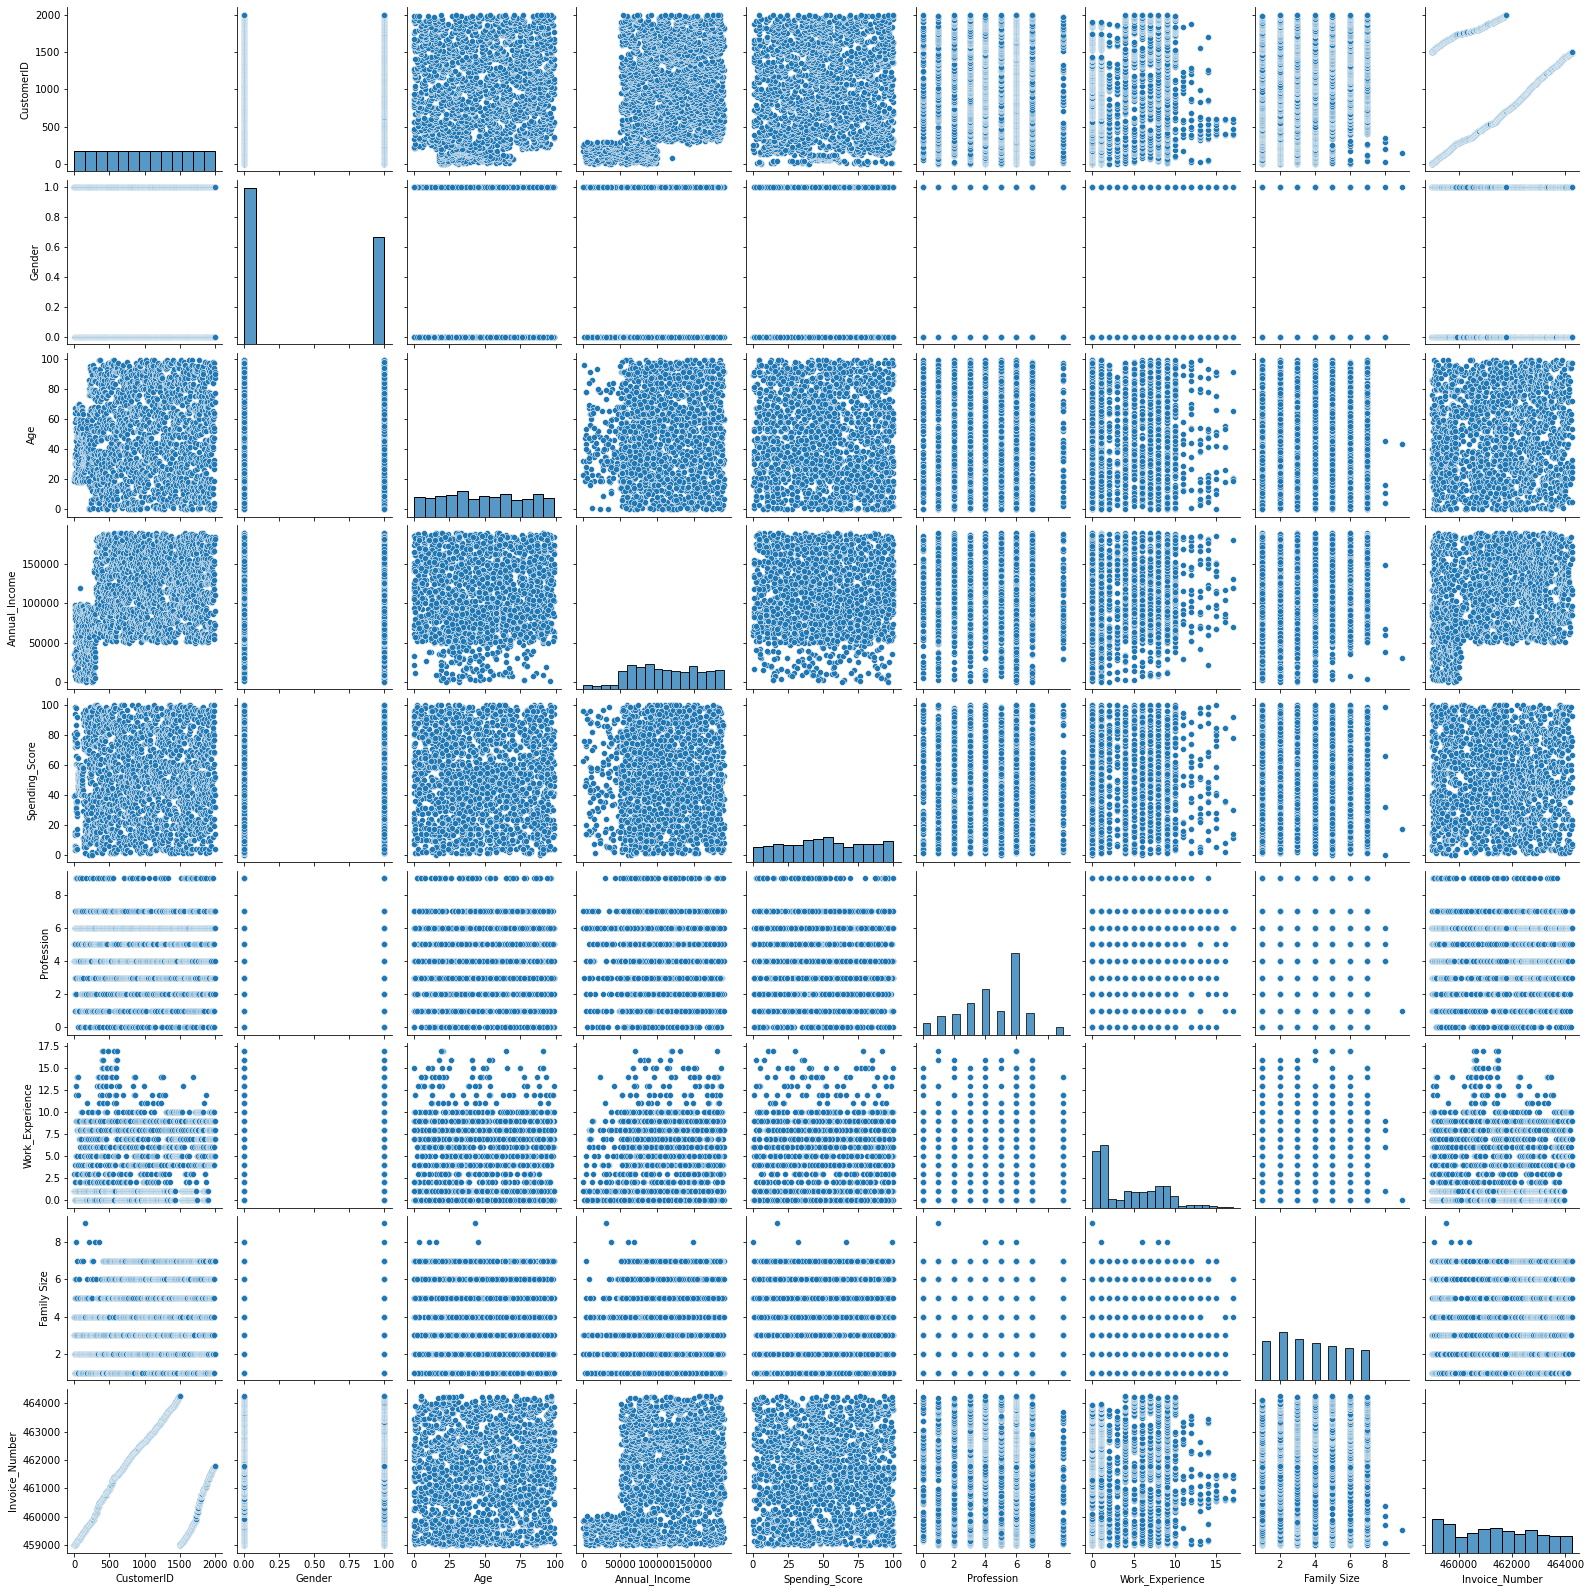

In [19]:
sns.pairplot(data)

<AxesSubplot:xlabel='Spending_Category', ylabel='count'>

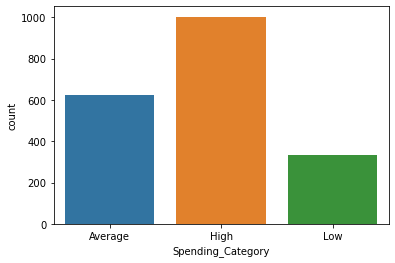

In [20]:
sns.countplot(x= data['Spending_Category'])

In [21]:
data['Spending_Category'].value_counts()

High       1003
Average     626
Low         336
Name: Spending_Category, dtype: int64

In [22]:
data.drop(columns = ['CustomerID','Spending_Score','Invoice_Number'])

,Gender,Age,Annual_Income,Profession,Work_Experience,Family Size,Spending_Category
0,1,19,15000,4.0,1,4,Average
1,1,21,35000,5.0,3,3,High
2,0,20,86000,5.0,1,1,Low
3,0,23,59000,1.0,0,2,High
4,0,31,38000,3.0,2,6,Average
...,...,...,...,...,...,...,...
1995,0,71,184387,6.0,8,7,Average
1996,0,91,73158,7.0,7,7,Average
1997,1,87,90961,4.0,9,2,Low
1998,1,77,182109,2.0,7,2,Low


In [62]:
d_low = data[data['Spending_Category']=='Low']
d_avg = data[data['Spending_Category']=='Average']
d_high = data[data['Spending_Category']=='High']

In [63]:
d_low_re = resample((d_low), replace=True,  n_samples= 1003, random_state=42)
d_avg_re = resample(d_avg, replace=True,  n_samples= 1003, random_state=42)
# d_high_re = resample(d_high, replace=True,  n_samples= 1003, random_state=42)

In [64]:
data1 = pd.concat([d_low_re,d_avg_re,d_high])

C:\Users\91808\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Spending_Category', ylabel='count'>

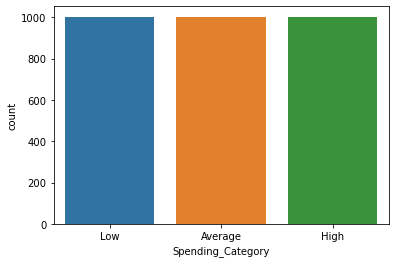

In [45]:
sns.countplot(data1['Spending_Category'])

In [46]:
x = data1.drop(columns = ['Spending_Category'])
y = data1['Spending_Category']

In [47]:
data1.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work_Experience,Family Size,Spending_Category,Invoice_Number
561,562,0,17,169496,12,1.0,11,6,Low,461340
1573,1574,0,59,163179,19,4.0,1,7,Low,459218
580,581,0,89,136037,1,0.0,5,1,Low,461430
381,382,1,90,70201,8,5.0,0,2,Low,460555
1081,1082,0,90,138013,16,6.0,8,7,Low,462900


In [48]:
scale = StandardScaler()
x_scaled = scale.fit_transform(x)

In [49]:
x_scaled

array([[-0.73562763, -0.82636911, -1.13442364, ...,  1.79488016,
         1.15025937, -0.02143199],
       [ 1.01725423, -0.82636911,  0.36926505, ..., -0.79841399,
         1.66203379, -1.39157059],
       [-0.70271779, -0.82636911,  1.4433284 , ...,  0.23890367,
        -1.40861276,  0.03667945],
       ...,
       [-0.88805214,  1.210113  , -1.02701731, ...,  3.35085665,
         0.63848494, -0.31069782],
       [-0.86033859, -0.82636911,  0.40506716, ..., -0.79841399,
         0.12671052, -0.26356298],
       [ 1.32729954, -0.82636911, -0.95541308, ...,  1.53555075,
         1.66203379, -0.77623502]])

In [50]:
xtrain,xtest,ytrain,ytest = train_test_split(x_scaled,y,test_size = 0.2,random_state = 42)

In [51]:
model1 = LogisticRegression()
model1.fit(xtrain,ytrain)

LogisticRegression()

In [52]:
model1.score(xtest,ytest)

0.9850498338870431

In [53]:
model2 = SVC()
model2.fit(xtrain,ytrain)

SVC()

In [54]:
model2.score(xtest,ytest)

0.96843853820598

In [55]:
model3 = DecisionTreeClassifier()
model3.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [56]:
model4 = DecisionTreeClassifier()
model4.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [57]:
model4.score(xtest,ytest)

1.0

In [58]:
model5 = RandomForestClassifier()
model5.fit(xtrain,ytrain)

RandomForestClassifier()

In [59]:
model5.score(xtest,ytest)

1.0

In [60]:
model6 = KNeighborsClassifier()
model6.fit(xtrain,ytrain)

KNeighborsClassifier()

In [61]:
model6.score(xtest,ytest)

0.8205980066445183

### K Nearest Neighbors Classifier

In [68]:
model_knn = KNeighborsClassifier()